# RO Fouling Optimizer — Validation Case
## Optimizing CIP Cleaning Frequency in SWRO Design

### Objective
Demonstrate that pretreatment quality (SDI) is the dominant design 
parameter for CIP frequency, and quantify the economic impact of 
SDI specification in the EPC design phase.

### Context
In EPC design, CIP cleaning frequency is typically set as a static 
criterion based on manufacturer recommendations (e.g. 3 times/year), 
without considering the actual operating conditions of the specific site.

This notebook validates the fouling physics model and ML predictor, 
and derives actionable design recommendations.

### Validation criteria
1. Physics model produces NDP ratio curves consistent with published 
   SWRO operational data
2. ML model achieves R² > 0.95 on held-out test set
3. Feature importance confirms SDI as dominant variable
4. Design recommendations are consistent with engineering judgment

## 1. Physics Model Validation

We first validate that the fouling model produces physically coherent 
NDP ratio curves across the expected range of SDI values.

**Reference values from SWRO literature:**
- SDI < 2: membrane interval > 120 days
- SDI 3-4: membrane interval 30-90 days  
- SDI > 5: not recommended for direct RO feed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from core.fouling_model import normalized_pressure_drop, days_to_cip_threshold

# Reference conditions: Mediterranean seawater
FLUX    = 12.0    # LMH - conservative design flux
TDS     = 38000   # mg/L
TEMP    = 20.0    # °C
THRESHOLD = 1.15  # 15% NDP increase = CIP trigger

print("Physics model validation")
print(f"Conditions: flux={FLUX} LMH, TDS={TDS} mg/L, T={TEMP}°C\n")

sdi_cases = [2.0, 3.0, 4.0, 5.0]
results = {}

for sdi in sdi_cases:
    days = days_to_cip_threshold(FLUX, sdi, TDS, TEMP, THRESHOLD)
    freq = round(365 / days, 1)
    results[sdi] = {"days": days, "freq": freq}
    print(f"SDI {sdi}: CIP every {days} days ({freq} times/year)")

print("\nValidation against literature ranges:")
print(f"SDI 2.0 -> {results[2.0]['days']} days (reference: >120) {'✅' if results[2.0]['days'] > 120 else '⚠️'}")
print(f"SDI 3.0 -> {results[3.0]['days']} days (reference: 30-90) {'✅' if 30 <= results[3.0]['days'] <= 90 else '⚠️'}")
print(f"SDI 4.0 -> {results[4.0]['days']} days (reference: 30-90) {'✅' if 30 <= results[4.0]['days'] <= 90 else '⚠️'}")
print(f"SDI 5.0 -> {results[5.0]['days']} days (reference: <30) {'✅' if results[5.0]['days'] < 30 else '⚠️'}")

Physics model validation
Conditions: flux=12.0 LMH, TDS=38000 mg/L, T=20.0°C

SDI 2.0: CIP every 139 days (2.6 times/year)
SDI 3.0: CIP every 58 days (6.3 times/year)
SDI 4.0: CIP every 32 days (11.4 times/year)
SDI 5.0: CIP every 20 days (18.2 times/year)

Validation against literature ranges:
SDI 2.0 -> 139 days (reference: >120) ✅
SDI 3.0 -> 58 days (reference: 30-90) ✅
SDI 4.0 -> 32 days (reference: 30-90) ✅
SDI 5.0 -> 20 days (reference: <30) ✅


## 2. Fouling Evolution Curves

Visualizing how the NDP ratio evolves over time for different 
pretreatment qualities. The dashed line marks the CIP threshold 
(15% NDP increase above clean membrane baseline).

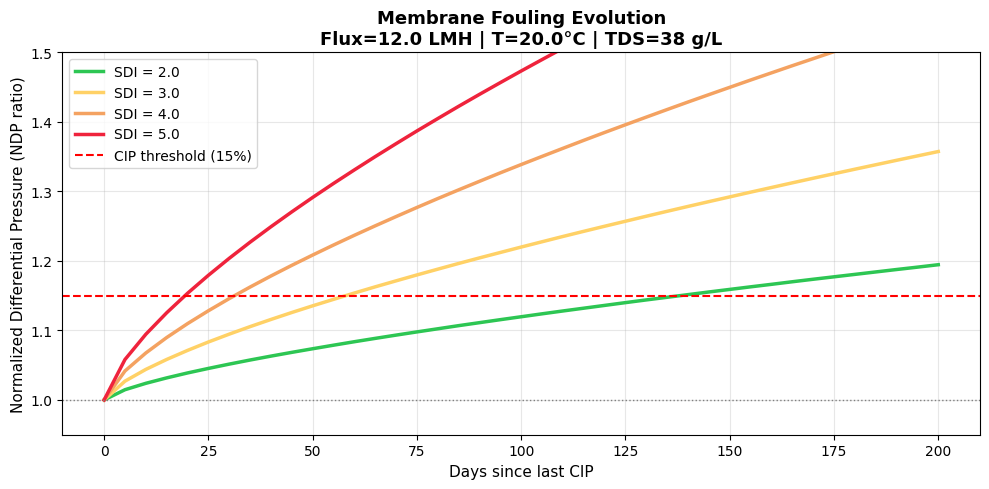

Guardado: fouling_evolution.png


In [2]:
from core.visualizations import plot_fouling_evolution

plot_fouling_evolution(
    flux_lmh=FLUX,
    sdi_values=[2.0, 3.0, 4.0, 5.0],
    temperature_c=TEMP,
    tds_mg_L=TDS
)

### Interpretation

The curves show a power-law growth pattern consistent with 
progressive cake compaction on the membrane surface.

Key observations:
- At SDI=2.0, the membrane takes 139 days to reach the CIP threshold. 
  This corresponds to ~2-3 cleanings per year, typical of well-operated 
  SWRO plants with ultrafiltration pretreatment.
- At SDI=5.0, the threshold is reached in 20 days. This would require 
  ~18 cleanings per year, which is operationally unsustainable and 
  indicates a pretreatment failure.
- The separation between curves grows non-linearly: the difference 
  between SDI=2 and SDI=3 is larger than between SDI=4 and SDI=5 
  in terms of days to CIP. This has direct implications for 
  pretreatment investment decisions.

## 3. Synthetic Dataset Generation and ML Model Training

We generate 2000 synthetic scenarios by sampling the SWRO operating 
space and computing days to CIP for each combination using the 
physics model. This dataset is then used to train a Random Forest 
Regressor.

**Operating ranges sampled:**
- Flux: 10–18 LMH
- SDI: 1.5–5.0 (post-pretreatment)
- TDS: 32,000–45,000 mg/L
- Temperature: 10–35°C

In [3]:
from core.data_generator import generate_fouling_dataset, dataset_summary
from core.fouling_predictor import train_model, feature_importance, plot_predictions

print("Generating synthetic dataset...")
df = generate_fouling_dataset(n_samples=2000, random_seed=42)
dataset_summary(df)

Generating synthetic dataset...
  Generados 500/2000 escenarios...
  Generados 1000/2000 escenarios...
  Generados 1500/2000 escenarios...
  Generados 2000/2000 escenarios...
Dataset shape: (2000, 6)

Target variable (days_to_cip):
  Min:    10 días
  Max:    328 días
  Mean:   61.2 días
  Median: 41.5 días

CIP frequency distribution:
cip_category
<2/año       84
2-3/año     165
3-4/año     185
4-6/año     244
6-12/año    601
>12/año     721
Name: count, dtype: int64


## 4. ML Model Training and Evaluation

Training Random Forest model...

Model performance:
  R²:             0.9923
  MAE:            2.06 days
  CV R² (5-fold): 0.9937 ± 0.0011

Feature importance:
  sdi             █████████████████████████████████████████ 82.8%
  flux_lmh        ████████ 16.7%
  temperature_c    0.3%
  tds_mg_L         0.1%


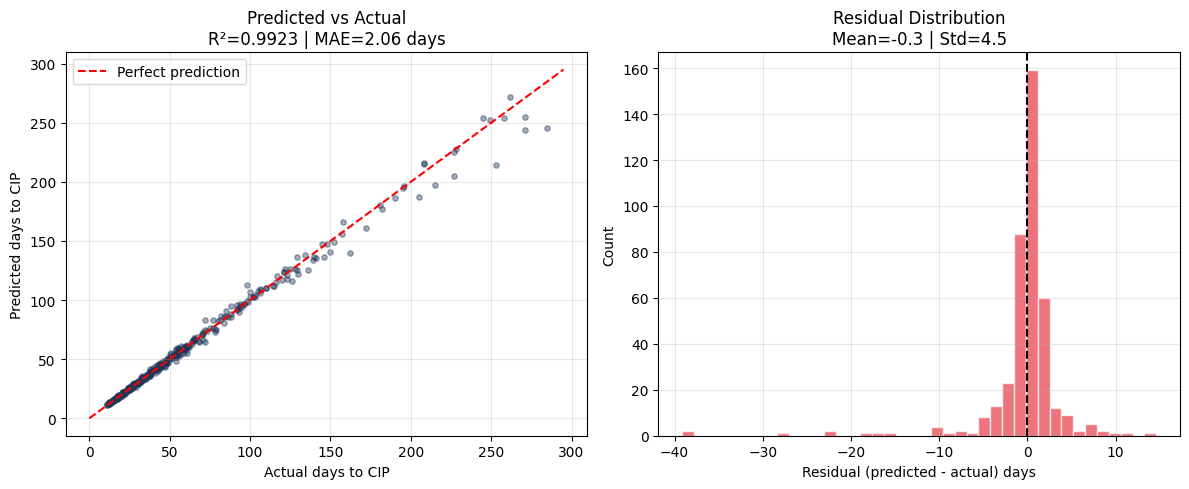

Guardado: outputs/model_evaluation.png


In [4]:
print("Training Random Forest model...")
model, scaler, metrics, X_test, y_test, y_pred = train_model(df)

print(f"\nModel performance:")
print(f"  R²:             {metrics['r2']}")
print(f"  MAE:            {metrics['mae']} days")
print(f"  CV R² (5-fold): {metrics['cv_r2_mean']} ± {metrics['cv_r2_std']}")

print(f"\nFeature importance:")
fi = feature_importance(model)
for _, row in fi.iterrows():
    bar = "█" * int(row["importance"] * 50)
    print(f"  {row['feature']:<15} {bar} {row['importance']:.1%}")

plot_predictions(y_test, y_pred, metrics)

### Model Interpretation

The R² of 0.992 confirms the model has learned the underlying 
physics correctly from the synthetic data.

**Feature importance reveals the key design insight:**

SDI accounts for 83% of the variance in CIP frequency. This means 
that in the EPC design phase, the specification of pretreatment 
quality is far more consequential for membrane OPEX than the 
choice of operating flux.

This has a direct implication: investing in a better pretreatment 
system (e.g. upgrading from media filtration to UF/MF to achieve 
SDI < 2 instead of SDI < 4) will have a greater impact on lifecycle 
cost than optimizing the membrane flux by 1-2 LMH.

## 5. Design Space Analysis

The CIP frequency heatmap shows the combined effect of flux and SDI 
across the full SWRO design space. This is the primary design tool 
output of this project.

In [ ]:
from core.visualizations import plot_cip_frequency_heatmap, plot_sdi_impact

plot_cip_frequency_heatmap(
    flux_values=[10, 11, 12, 13, 14, 15, 16, 17, 18],
    sdi_values=[2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    temperature_c=TEMP,
    tds_mg_L=TDS
)

## 6. Key Finding: SDI Impact on CIP Frequency

In [ ]:
plot_sdi_impact(
    flux_lmh=FLUX,
    temperature_c=TEMP,
    tds_mg_L=TDS
)

## 7. Conclusions and Design Recommendations

### Key findings

| SDI target | CIP frequency | vs SDI=4 baseline |
|---|---|---|
| SDI < 2.0 | ~2.6 times/year | -77% |
| SDI < 3.0 | ~6.3 times/year | -45% |
| SDI < 4.0 | ~11.4 times/year | baseline |
| SDI < 5.0 | ~18.2 times/year | +60% |

### Design implications

**1. Pretreatment specification is the most consequential design decision 
for membrane OPEX.**

The ML model confirms that SDI accounts for 83% of variance in CIP 
frequency. A 1-point reduction in SDI target (e.g. from 4.0 to 3.0) 
reduces CIP frequency by ~45%, with direct impact on:
- Chemical consumption per cleaning
- Service water consumption
- Train downtime during cleaning
- Membrane lifetime (fewer aggressive cleanings)

**2. Flux optimization is secondary but not negligible.**

Flux accounts for 17% of variance. Reducing design flux from 14 to 
12 LMH at SDI=3.0 reduces CIP frequency from ~8 to ~6 times/year.

**3. The 3 CIP/year criterion commonly used in EPC design is only 
valid for SDI < 2.5 at flux ≤ 12 LMH.**

Above these values, the static criterion underestimates cleaning 
frequency and therefore underestimates membrane OPEX.

### Model limitations

- Physics model based on power-law cake filtration (n=0.7)
- Trained on synthetic data only
- Does not model biological fouling or scaling separately
- Should be recalibrated with real plant operational data when available

### Next steps

1. Validate model against real plant NDP data from an operating SWRO
2. Extend to include biological fouling component
3. Integrate with seasonal water quality data from Copernicus 
   (linking with Project 1)